In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.data.load import load_raw, describe_target
from src.data.split import time_split

df = load_raw()
describe_target(df)

Total transactions : 590,540
Fraud              : 20,663  (3.50%)
Legit              : 569,877
Identity match     : 144,233  (24.4%)
TransactionDT range: 86,400 → 15,811,131  (seconds)


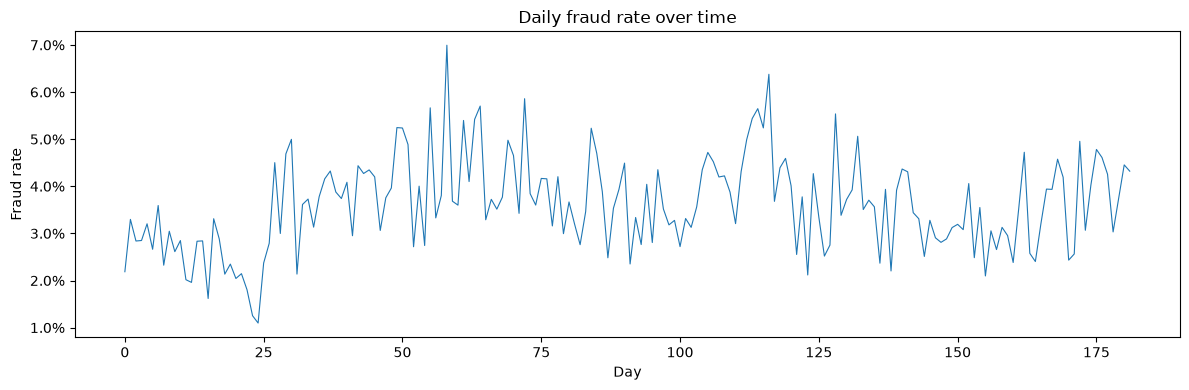

In [3]:
df["day"] = (df["TransactionDT"] - df["TransactionDT"].min()) // 86400

daily = df.groupby("day")["isFraud"].agg(["sum", "count"])
daily["fraud_rate"] = daily["sum"] / daily["count"] * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily["fraud_rate"], linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Day")
ax.set_ylabel("Fraud rate")
ax.set_title("Daily fraud rate over time")
plt.tight_layout()
plt.savefig("../reports/figures/fraud_rate_over_time.png", dpi=150)
plt.show()

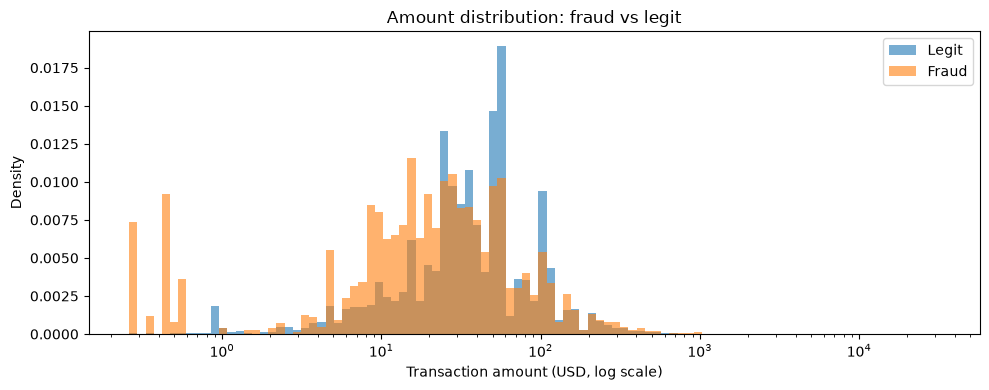

In [5]:
import numpy as np

bins = np.logspace(
    np.log10(df["TransactionAmt"].min() + 0.01),
    np.log10(df["TransactionAmt"].max()),
    100
)

fig, ax = plt.subplots(figsize=(10, 4))
for label, group in df.groupby("isFraud"):
    ax.hist(group["TransactionAmt"], bins=bins, alpha=0.6,
            label="Fraud" if label else "Legit", density=True)
ax.set_xscale("log")
ax.set_xlabel("Transaction amount (USD, log scale)")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Amount distribution: fraud vs legit")
plt.tight_layout()
plt.savefig("../reports/figures/amount_distribution.png", dpi=150)
plt.show()

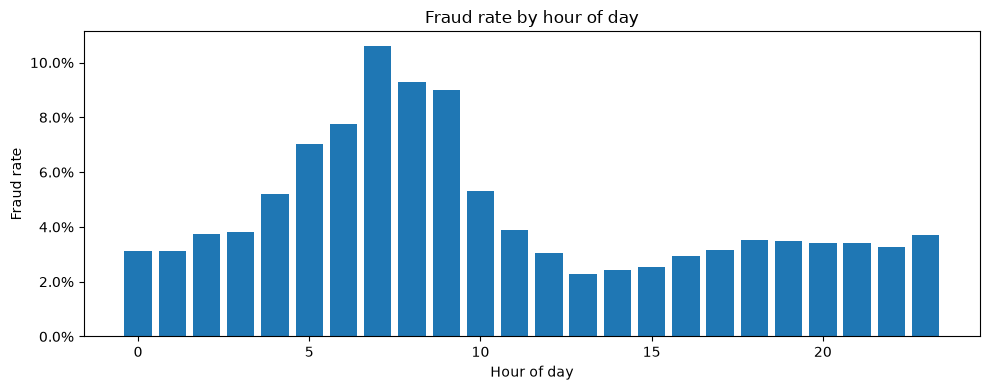

In [6]:
df["hour"] = (df["TransactionDT"] // 3600) % 24

hourly = df.groupby("hour")["isFraud"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate")
ax.set_title("Fraud rate by hour of day")
plt.tight_layout()
plt.savefig("../reports/figures/fraud_by_hour.png", dpi=150)
plt.show()

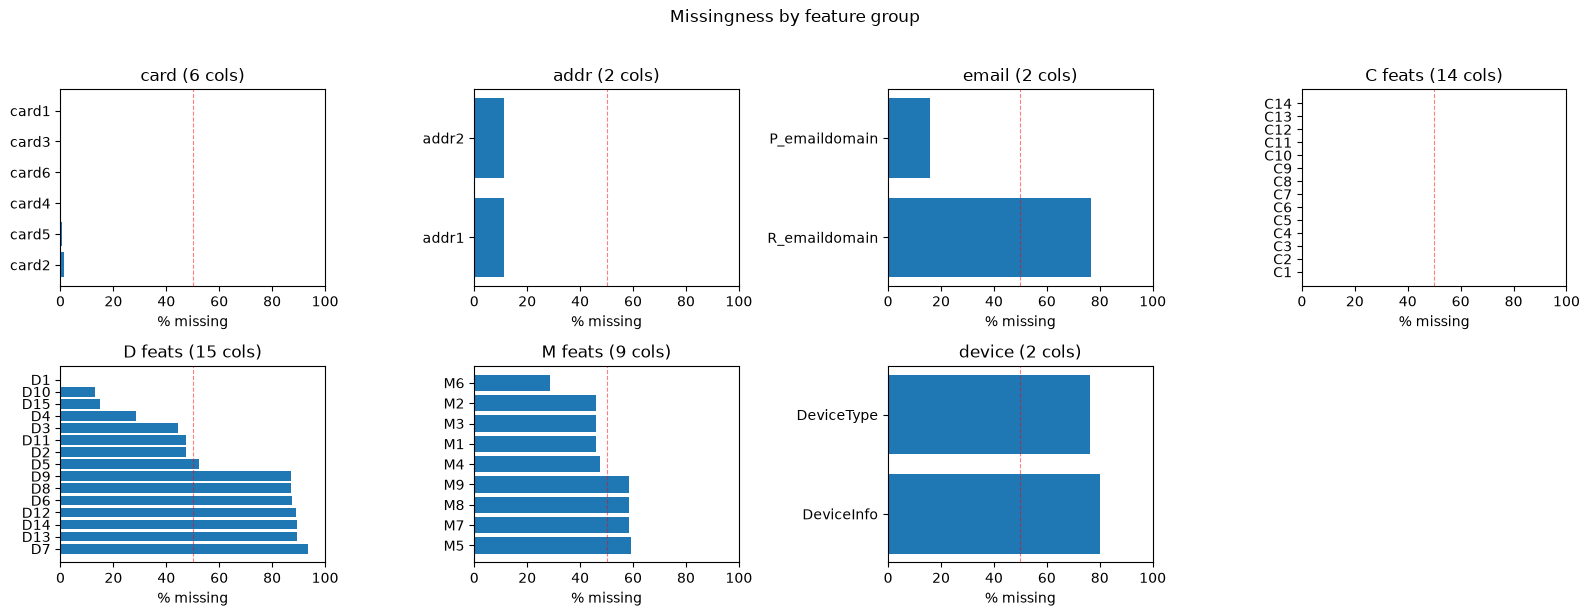

In [10]:
import re

groups = {
    "card":    [c for c in df.columns if re.match(r'^card\d+$', c)],
    "addr":    [c for c in df.columns if re.match(r'^addr\d+$', c)],
    "email":   [c for c in df.columns if "emaildomain" in c],
    "C feats": [c for c in df.columns if re.match(r'^C\d+$', c)],
    "D feats": [c for c in df.columns if re.match(r'^D\d+$', c)],
    "M feats": [c for c in df.columns if re.match(r'^M\d+$', c)],
    "device":  [c for c in df.columns if c.startswith("Device")],
}

miss = df.isnull().mean() * 100 

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, (name, cols) in zip(axes.flat, groups.items()):
    vals = miss[cols].sort_values(ascending=False)
    ax.barh(vals.index, vals.values)
    ax.set_xlim(0, 100)
    ax.set_title(f"{name} ({len(cols)} cols)")
    ax.set_xlabel("% missing")
    ax.axvline(50, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
axes.flat[-1].set_visible(False)

plt.suptitle("Missingness by feature group", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/missingness_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

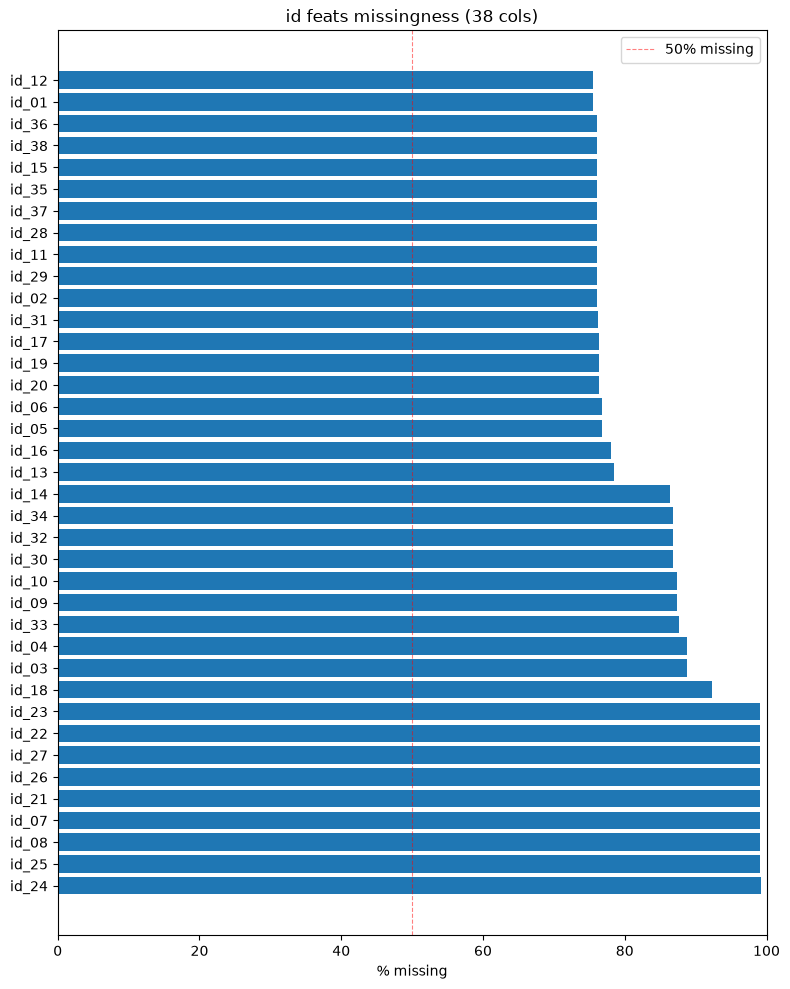

In [11]:
id_cols = [c for c in df.columns if re.match(r'^id_\d+$', c)]
id_miss  = miss[id_cols].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(id_miss.index, id_miss.values)
ax.set_xlim(0, 100)
ax.axvline(50, color="red", linestyle="--", linewidth=0.8, alpha=0.5, label="50% missing")
ax.set_xlabel("% missing")
ax.set_title(f"id feats missingness ({len(id_cols)} cols)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/id_feats_missingness.png", dpi=150)
plt.show()

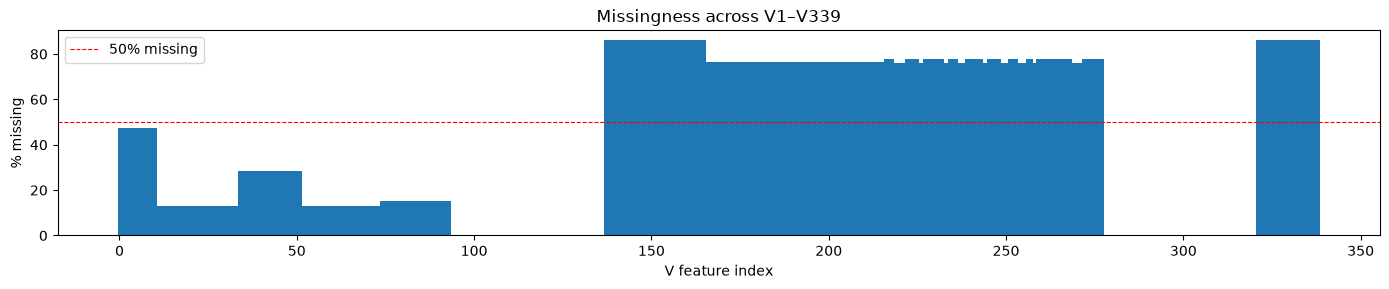

V features >50% missing: 159 / 339
V features >90% missing: 0 / 339


In [12]:
v_cols = [c for c in df.columns if c.startswith("V")]
v_miss = df[v_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(len(v_miss)), v_miss.values, width=1.0)
ax.axhline(50, color="red", linestyle="--", linewidth=0.8, label="50% missing")
ax.set_xlabel("V feature index")
ax.set_ylabel("% missing")
ax.set_title("Missingness across V1–V339")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/v_features_missingness.png", dpi=150)
plt.show()

# how many V features are >50% missing?
print(f"V features >50% missing: {(v_miss > 50).sum()} / {len(v_cols)}")
print(f"V features >90% missing: {(v_miss > 90).sum()} / {len(v_cols)}")

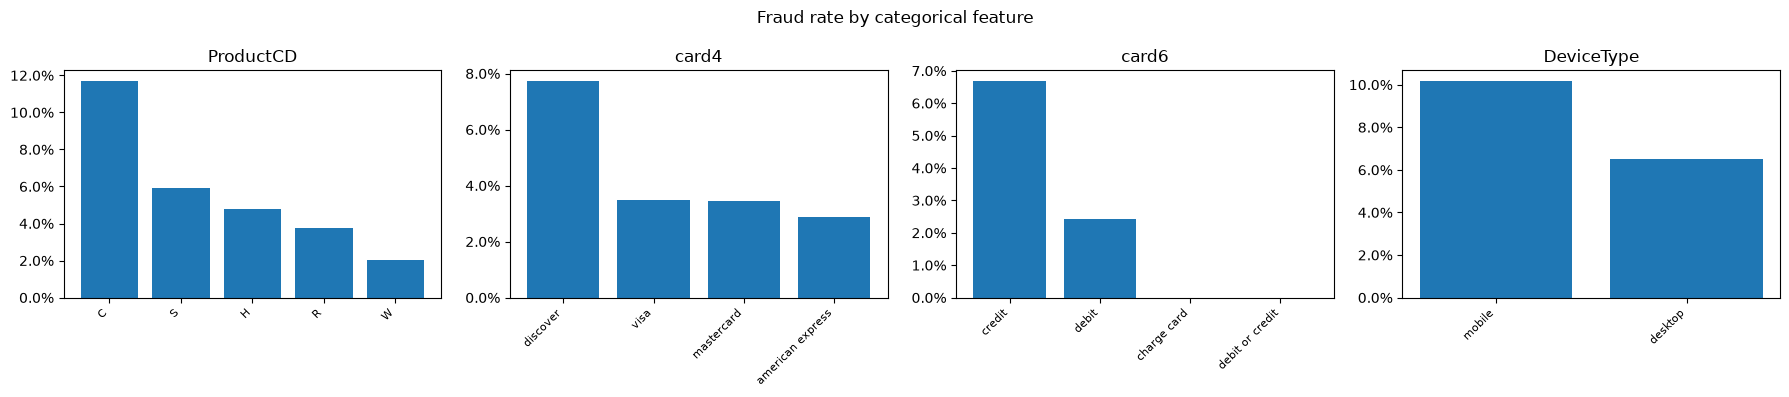

In [14]:
cat_cols = ["ProductCD", "card4", "card6",  "DeviceType"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    rates = (df.groupby(col)["isFraud"]
               .mean()
               .sort_values(ascending=False) * 100)
    ax.bar(range(len(rates)), rates.values)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(col)

plt.suptitle("Fraud rate by categorical feature")
plt.tight_layout()
plt.savefig("../reports/figures/fraud_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

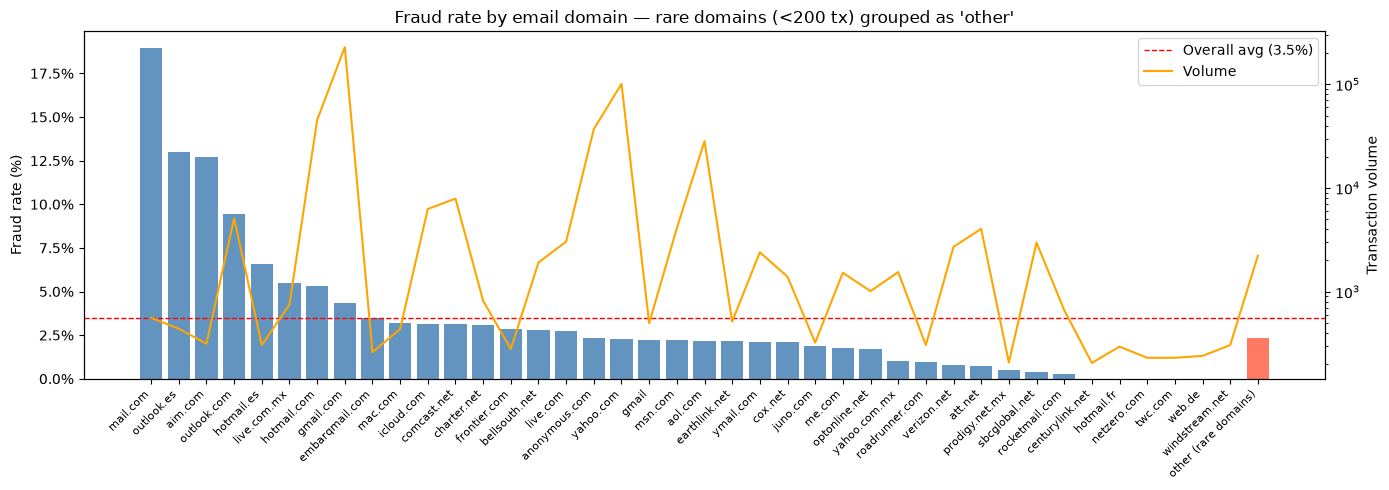

Named domains  : 40 (volume ≥ 200)
Rare domains   : 19 (volume < 200)
Other bucket fraud rate: 2.3%


In [16]:
min_count = 200

email_stats = (
    df.groupby("P_emaildomain")["isFraud"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "fraud_rate", "count": "volume"})
)
email_stats["fraud_rate"] *= 100

# split into named and other
named  = email_stats[email_stats["volume"] >= min_count].sort_values("fraud_rate", ascending=False)
other_rows = email_stats[email_stats["volume"] < min_count]

# aggregate "other" into one row
other = pd.DataFrame([{
    "fraud_rate": other_rows.apply(
        lambda x: (x["fraud_rate"] / 100 * x["volume"]).sum(), axis=1
    ).sum() / other_rows["volume"].sum() * 100,
    "volume": other_rows["volume"].sum()
}], index=["other (rare domains)"])

# combine
combined = pd.concat([named, other])

fig, ax1 = plt.subplots(figsize=(14, 5))

colors = ["tomato" if i == len(combined) - 1 else "steelblue" 
          for i in range(len(combined))]

bars = ax1.bar(range(len(combined)), combined["fraud_rate"], 
               color=colors, alpha=0.85)
ax1.set_ylabel("Fraud rate (%)")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.axhline(df["isFraud"].mean() * 100, color="red", linestyle="--",
            linewidth=1, label=f"Overall avg ({df['isFraud'].mean()*100:.1f}%)")

ax2 = ax1.twinx()
ax2.plot(range(len(combined)), combined["volume"],
         color="orange", linewidth=1.5, label="Volume")
ax2.set_ylabel("Transaction volume")
ax2.set_yscale("log")

ax1.set_xticks(range(len(combined)))
ax1.set_xticklabels(combined.index, rotation=45, ha="right", fontsize=8)
ax1.set_title(f"Fraud rate by email domain — rare domains (<{min_count} tx) grouped as 'other'")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig("../reports/figures/fraud_rate_by_email_domain.png", dpi=150)
plt.show()

print(f"Named domains  : {len(named)} (volume ≥ {min_count})")
print(f"Rare domains   : {len(other_rows)} (volume < {min_count})")
print(f"Other bucket fraud rate: {other['fraud_rate'].iloc[0]:.1f}%")